In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import wasserstein_distance, ks_2samp, chi2_contingency, entropy, pointbiserialr
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import warnings
from sklearn.metrics import mean_squared_error
from scipy.stats import chi2_contingency
from Scripts import test_onehot_fields, test_categorical_fields, test_numerical_fields, analyze_onehot_correlations, analyze_categorical_correlations, compare_correlation_between_num_fields_and_cat


In [35]:
ONEHOT_FIELDS = ['PaymentSystem', 'OpType', 'DETAILEDCARDTYPE', 'TRANMETHOD', 'ISOWNTERMINAL', 
                'NAME', 'MCC', 'DEVICETYPE', 'CurrencyName', 'CITY', 'REGION', 'ISVIRTUALTRANSACTION']
CATEGORICAL_FIELDS = ['ACCOUNT_ID', 'TERMINAL_CODE', 'CARD', 'TRANS_DETAIL']
NUMERICAL_FIELDS = ['AMOUNT_EQ', 'EXCHANGE_RATA']
real_data = pd.read_csv('Data/Sber/Clear/transact_compare.csv')  # Реальные данные
synth_data = pd.read_csv('Data/Sber/Clear/transact_400000_samples.csv')

In [ ]:
test_onehot_fields(real_data, synth_data, ONEHOT_FIELDS)

In [ ]:
test_categorical_fields(real_data, synth_data, CATEGORICAL_FIELDS)



NUMERICAL ANALYSIS: AMOUNT_EQ


C:\Users\kiril\AppData\Local\Temp\ipykernel_27148\1671946525.py:82: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0, 1].boxplot([real_data, synth_data],


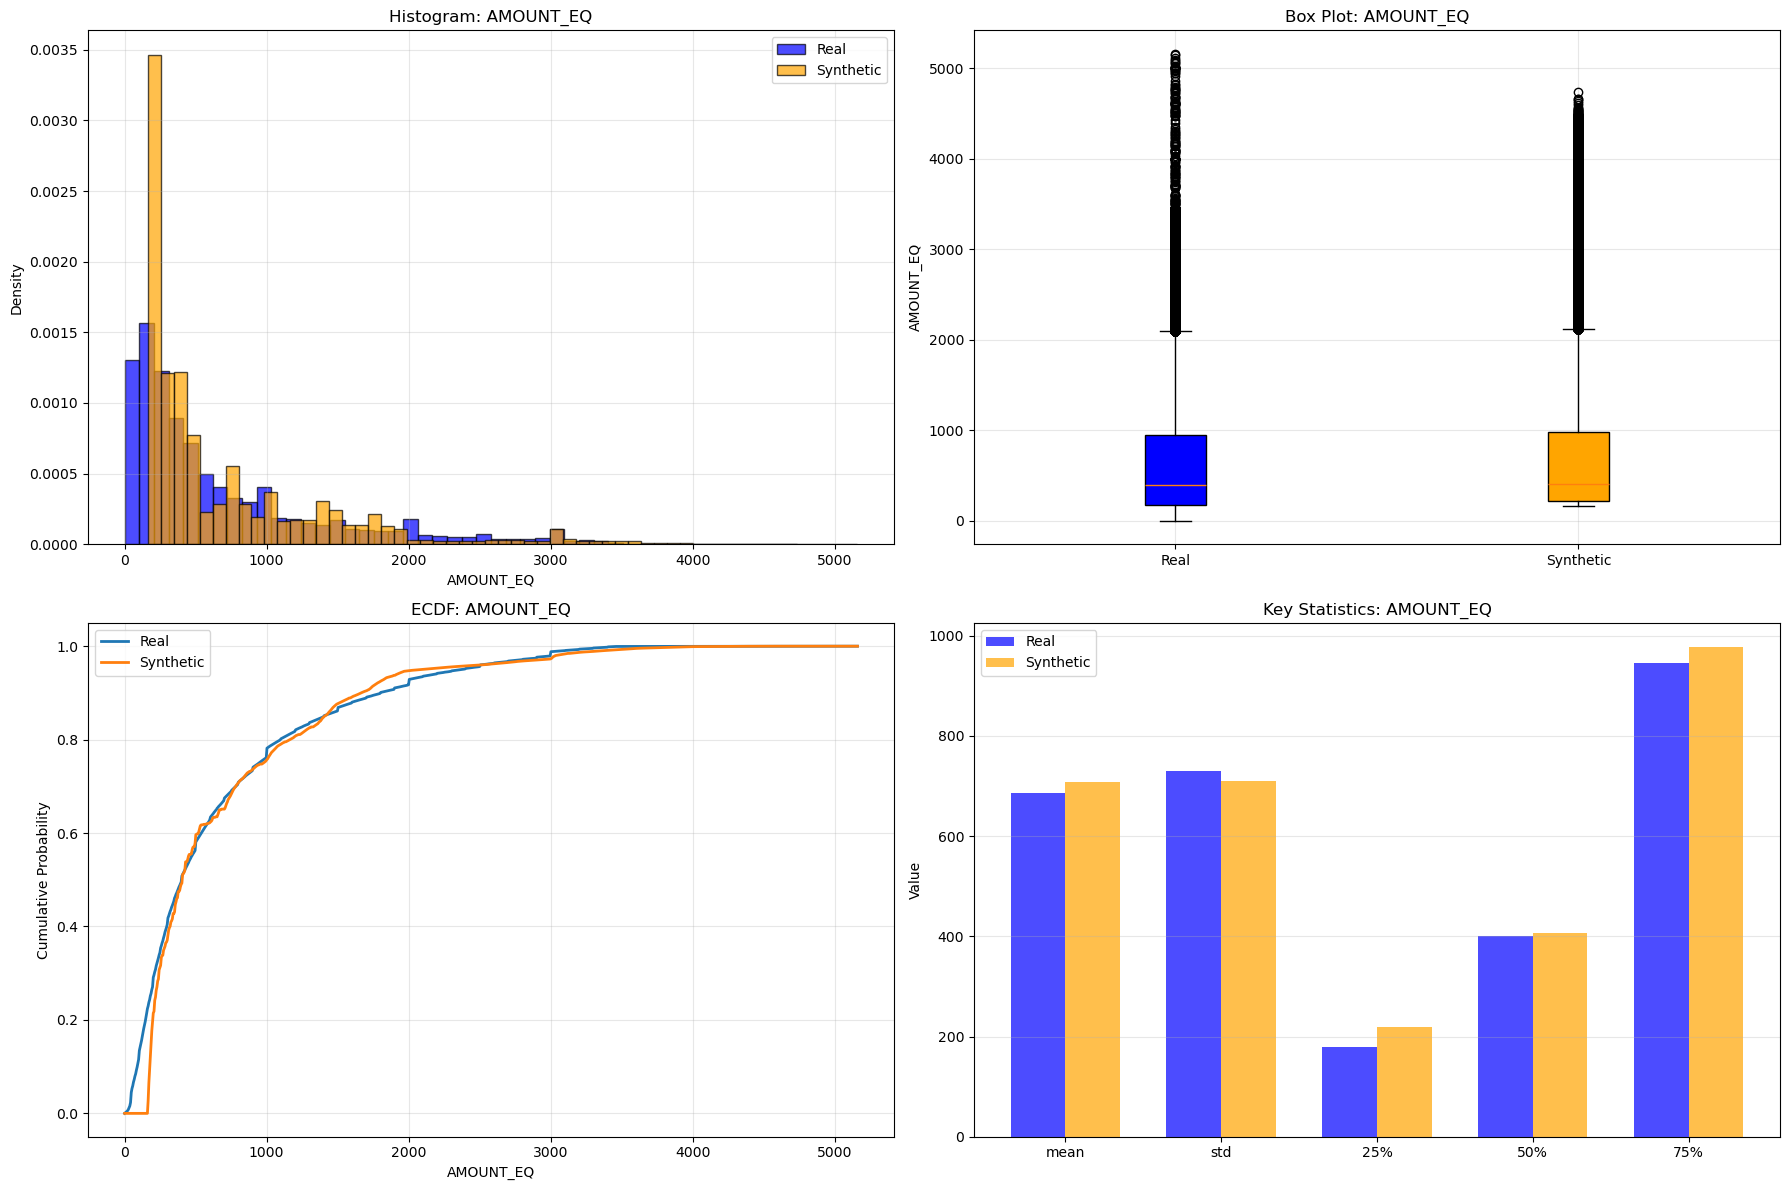

KS Test: statistic=0.2250, p-value=0.0000
Wasserstein Distance: 59.4312
Mean difference: 3.4%
Std difference: 2.7%
Median difference: 1.7%

Basic Statistics:
            count     mean      std     min    25%      50%     75%      max  \
Real       275259  685.463  729.506    0.01  180.0  400.000  946.00  5160.00   
Synthetic  400000  708.522  709.456  161.84  218.1  406.745  976.99  4731.88   

           skewness  kurtosis  
Real          1.692     2.471  
Synthetic     1.971     4.080  

NUMERICAL ANALYSIS: EXCHANGE_RATA


C:\Users\kiril\AppData\Local\Temp\ipykernel_27148\1671946525.py:82: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0, 1].boxplot([real_data, synth_data],


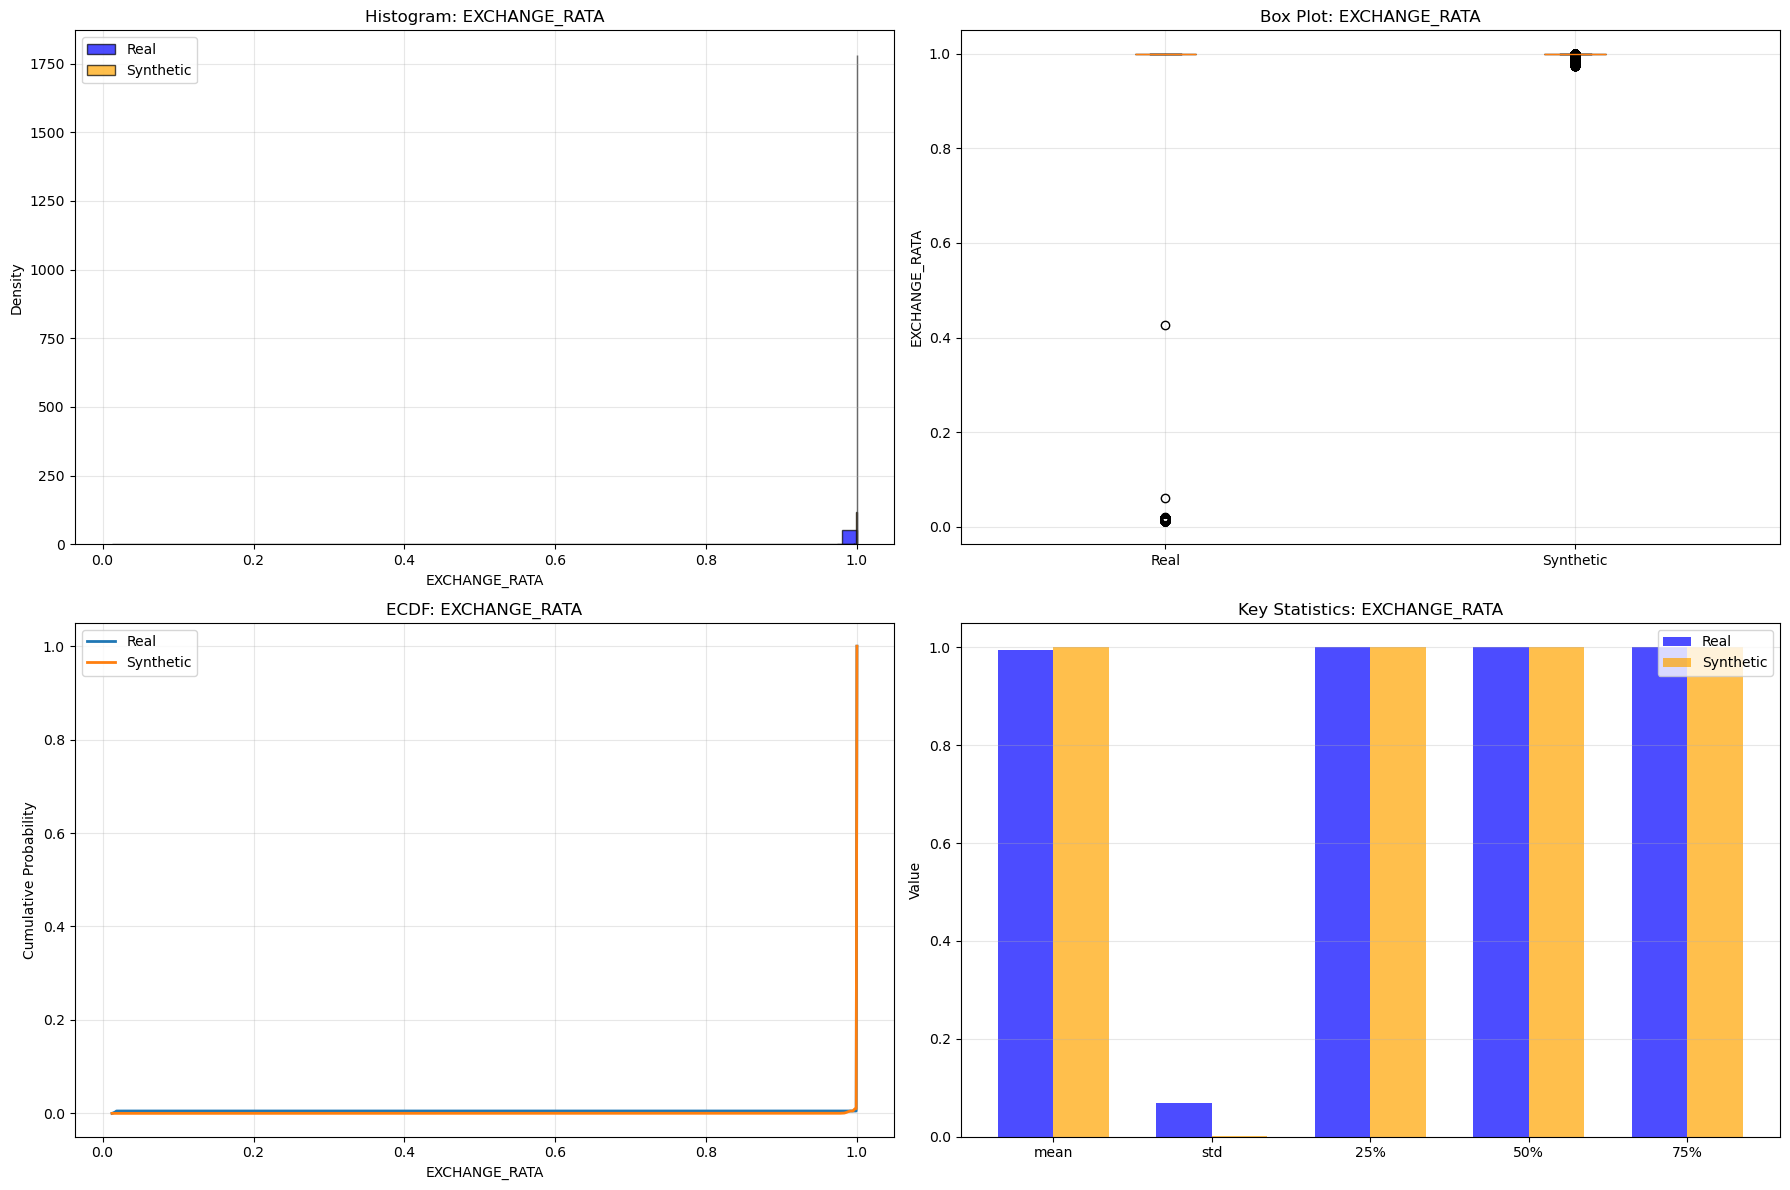

KS Test: statistic=0.9843, p-value=0.0000
Wasserstein Distance: 0.0051
Mean difference: 0.5%
Std difference: 98.5%
Median difference: 0.0%

Basic Statistics:
            count   mean    std    min  25%  50%  75%  max  skewness  kurtosis
Real       275259  0.995  0.070  0.012  1.0  1.0  1.0  1.0   -13.947   192.534
Synthetic  400000  1.000  0.001  0.974  1.0  1.0  1.0  1.0   -13.741   212.870


In [37]:
test_numerical_fields(real_data, synth_data, NUMERICAL_FIELDS)


CORRELATION ANALYSIS CATEGORICAL FIELDS

1. Categorical Feature


  Mean absolute difference (Cramér's V): 0.3651
  Max absolute difference (Cramér's V): 0.4192
  Cramér's V preservation score: 0.635


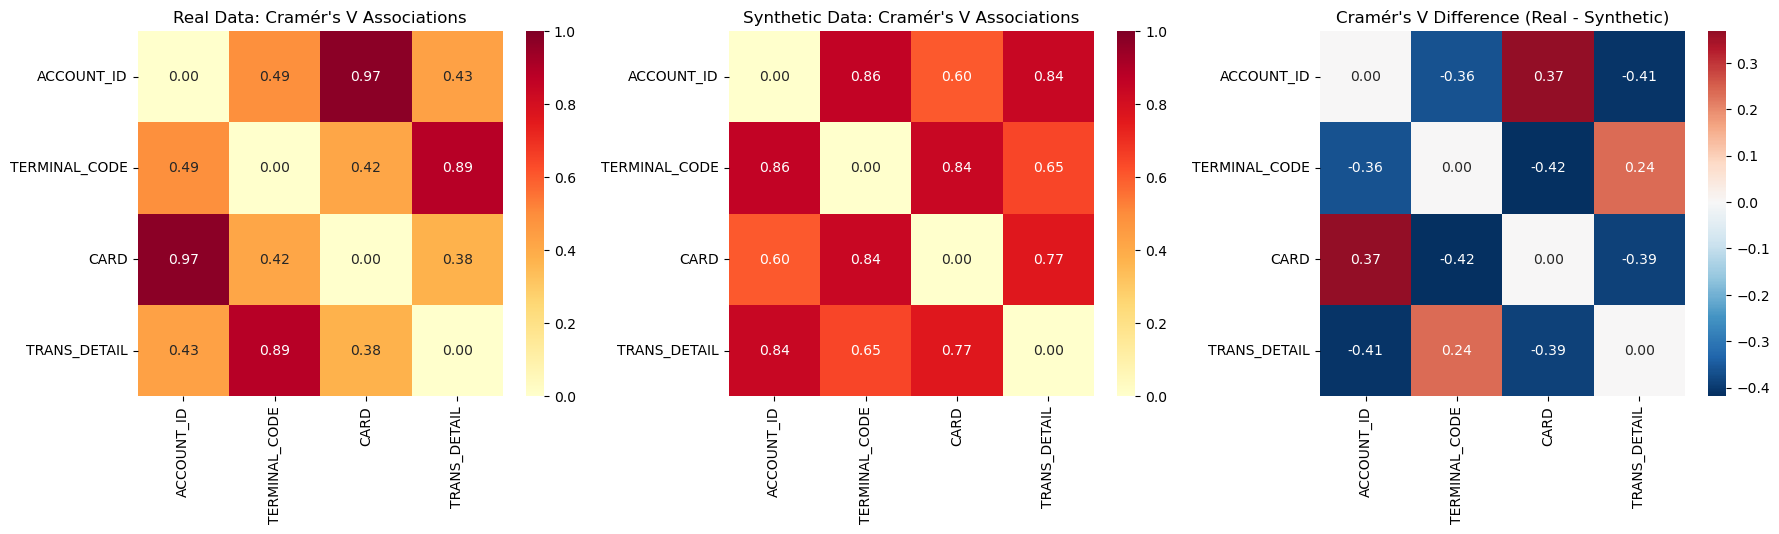

{'categorical_associations': {'mean_absolute_difference': np.float64(0.3651499807170427),
  'max_absolute_difference': np.float64(0.4191564549406688),
  'cramers_v_preservation_score': np.float64(0.6348500192829574)}}

In [ ]:
analyze_categorical_correlations(real_data, synth_data, CATEGORICAL_FIELDS)


ONE-HOT FIELD CORRELATION ANALYSIS
Available one-hot fields: 12

1. Cramér's V Correlation Matrices for One-Hot Fields:


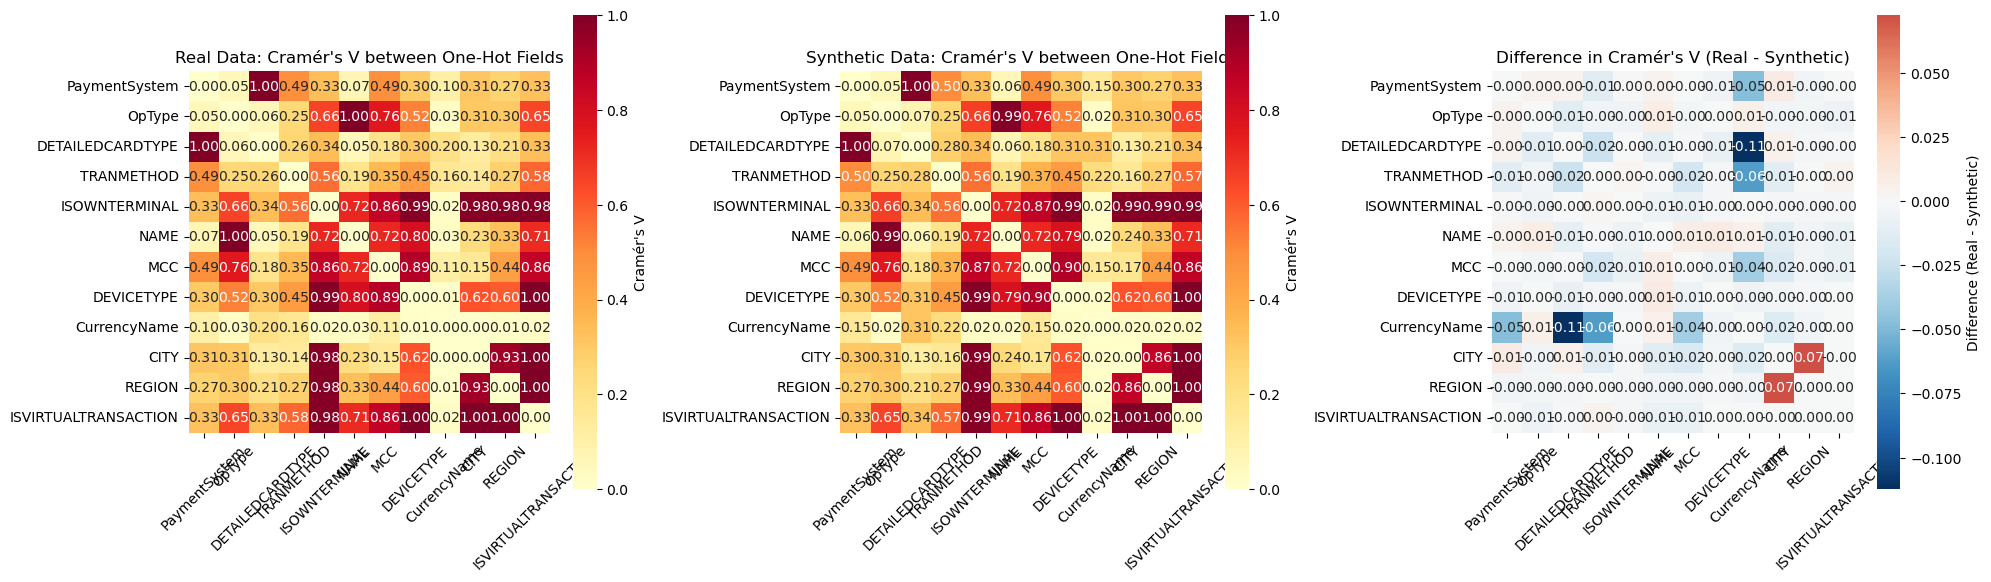


2. Correlation Difference Statistics:
   Mean absolute difference: 0.0100
   Median absolute difference: 0.0046
   Max absolute difference: 0.1123
   Std of differences: 0.0183
   Correlation preservation score: 0.990

3. Top 5 Pairs with Largest Differences:
   DETAILEDCARDTYPE vs CurrencyName:
     Real Cramér's V: 0.201
     Synthetic Cramér's V: 0.314
     Difference: -0.112
   CITY vs REGION:
     Real Cramér's V: 0.933
     Synthetic Cramér's V: 0.860
     Difference: 0.072
   TRANMETHOD vs CurrencyName:
     Real Cramér's V: 0.162
     Synthetic Cramér's V: 0.225
     Difference: -0.062
   PaymentSystem vs CurrencyName:
     Real Cramér's V: 0.103
     Synthetic Cramér's V: 0.150
     Difference: -0.047
   MCC vs CurrencyName:
     Real Cramér's V: 0.110
     Synthetic Cramér's V: 0.148
     Difference: -0.039


In [52]:
analyze_onehot_correlations(real_data, synth_data, ONEHOT_FIELDS)

In [70]:
compare_correlation_between_num_fields_and_cat(real_data, synth_data, num_field='EXCHANGE_RATA', cat_field='CurrencyName')


4. EXCHANGE_RATA vs CurrencyName Analysis:
EXCHANGE_RATA Statistics by Currency:
Currency             Real Mean    Synth Mean   Diff %    
------------------------------------------------------------
Евро                 0.0139       0.9997       7082.3    %
Доллар США           0.0168       0.9997       5846.3    %
Рубль                1.0000       0.9997       0.0       %
